
# 🛰️ Lab 5: การจัดการข้อมูล Raster ด้วย Rasterio
## วิชา GE 234 Basic Programming for Geographers

### 🎯 **วัตถุประสงค์**
1. เรียนรู้การใช้ **Rasterio** ในการอ่านและแสดงผลข้อมูล Raster
2. สามารถเข้าถึงข้อมูลเมตาของไฟล์ Raster เช่น ค่า Resolution และ CRS (Coordinate Reference System)
3. ใช้ **Rasterio** ในการตัด (Clip), บันทึก (Save), และวิเคราะห์ข้อมูล Raster
4. คำนวณค่าดัชนีพืชพรรณ **NDVI (Normalized Difference Vegetation Index)** จากข้อมูล Raster

---

## 🔹 ตัวอย่างที่ 1: อ่านข้อมูล Raster ด้วย Rasterio


In [54]:
import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "/content/drive/MyDrive/EarthEngine/ndvi_ayutthaya.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)

ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 8690, 'height': 8912, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 47N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",99],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32647"]]'), 'transform': Affine(10.0, 0.0, 629130.0,
       0.0, -10.0, 1637170.0)}



## 🔹 ตัวอย่างที่ 2: แสดงผลข้อมูล Raster ด้วย Matplotlib


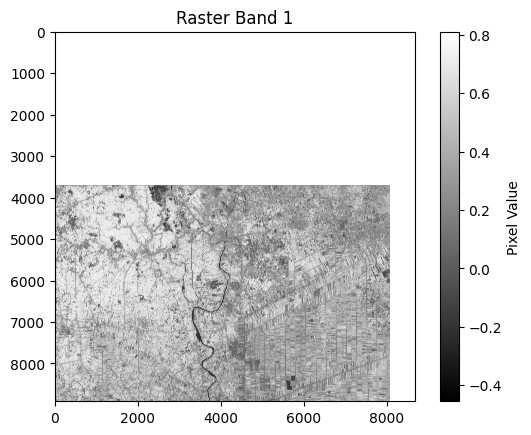

In [55]:

import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()



## 🔹 ตัวอย่างที่ 3: คำนวณค่า NDVI จากภาพ Raster


[[       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]
 ...
 [0.55020082 0.62449598 0.62453622 ...        nan        nan        nan]
 [0.54947585 0.62256616 0.62441081 ...        nan        nan        nan]
 [0.56416839 0.61710691 0.64423305 ...        nan        nan        nan]]


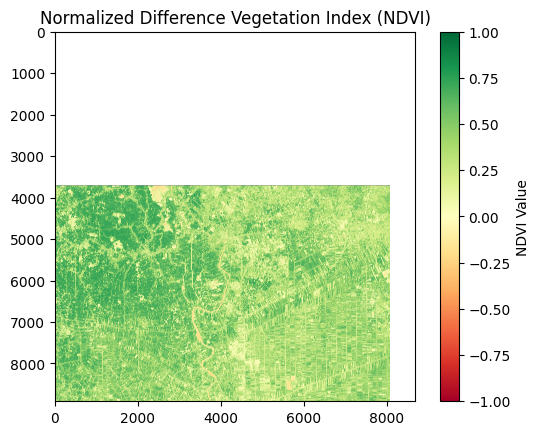

In [56]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# เปิดไฟล์ภาพดาวเทียม (ซึ่งเป็นไฟล์ NDVI ที่คำนวณมาแล้ว)
with rasterio.open(raster_path) as dataset:
    # เนื่องจากไฟล์ ndvi_ayutthaya.tif มีเพียง 1 band ที่เป็นค่า NDVI อยู่แล้ว
    # เราจึงอ่าน band ที่ 1 โดยตรง ไม่ต้องคำนวณ NIR และ Red
    ndvi = dataset.read(1).astype(float)

# ตรวจสอบค่า ndvi
print(ndvi)

# แสดงผล NDVI
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI)")
plt.show()



## 🔹 ตัวอย่างที่ 4: บันทึก NDVI เป็นไฟล์ GeoTIFF


In [57]:

# บันทึกไฟล์ NDVI เป็น GeoTIFF
ndvi_output = "ndvi_output.tif"
with rasterio.open(raster_path) as src:
    profile = src.profile
    profile.update(dtype=rasterio.float32, count=1)

    with rasterio.open(ndvi_output, "w", **profile) as dst:
        dst.write(ndvi.astype(rasterio.float32), 1)

print("บันทึกไฟล์ NDVI เรียบร้อย!")


บันทึกไฟล์ NDVI เรียบร้อย!



## 🔹 ตัวอย่างที่ 5: ตัด (Clip) ข้อมูล Raster ตามขอบเขตที่กำหนด


In [58]:
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping

# โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
# หลังจากอัปโหลดไฟล์ Shapefile ของคุณแล้ว ให้เปลี่ยน 'Province_Clip.shp' เป็นชื่อไฟล์ของคุณ
shapefile_path = "/content/Province_Clip.shp"  # ใส่ path ของไฟล์ขอบเขตที่อัปโหลด
gdf = gpd.read_file(shapefile_path)

# แปลง Polygon เป็นรูปแบบ GeoJSON
geometry = [mapping(gdf.geometry[0])]

# ตัดภาพ Raster
with rasterio.open(raster_path) as src:
    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่
out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform})

# บันทึกไฟล์ที่ถูกตัด
clipped_raster = "clipped_output.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("ตัดข้อมูล Raster สำเร็จ!")

ตัดข้อมูล Raster สำเร็จ!


In [59]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



# 📝 **กิจกรรมในแลป**

1. **แบบฝึกหัด 1**: ใช้ **Rasterio** อ่านข้อมูลภาพ **Raster** และแสดงผลด้วย Matplotlib  
2. **แบบฝึกหัด 2**: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้  
3. **แบบฝึกหัด 3**: ใช้ **NumPy และ Rasterio** คำนวณค่า NDVI และแสดงผลแผนที่  
4. **แบบฝึกหัด 4**: ใช้ **Rasterio** ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile  


In [60]:
from google.colab import drive
drive.mount('/content/drive')

# หลังจากเมานต์ไดรฟ์แล้ว คุณสามารถระบุ path ของไฟล์ได้ดังนี้
raster_path = '/content/drive/MyDrive/EarthEngine/ndvi_ayutthaya.tif'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### แบบฝึกที่ 1



#### **ขั้นตอนที่ 1: นำเข้าไลบรารีที่จำเป็น**

เราจะนำเข้า `rasterio` เพื่อจัดการข้อมูล Raster และ `matplotlib.pyplot` เพื่อใช้ในการสร้างกราฟและแสดงผลภาพครับ

In [61]:
import rasterio
import matplotlib.pyplot as plt

# ตรวจสอบว่า raster_path ถูกกำหนดค่าแล้ว
# print(raster_path)

#### **ขั้นตอนที่ 2: เปิดไฟล์ Raster**

เราจะใช้ `rasterio.open()` เพื่อเปิดไฟล์ภาพ Raster ที่ระบุโดย `raster_path` ซึ่งเป็นไฟล์ `ndvi_ayutthaya.tif` ที่เรากำหนดไว้ก่อนหน้านี้ครับ

การใช้ `with` statement จะช่วยให้แน่ใจว่าไฟล์จะถูกปิดอย่างถูกต้องหลังจากที่เราทำงานเสร็จแล้ว

In [62]:
with rasterio.open(raster_path) as dataset:
    # เราสามารถตรวจสอบข้อมูลเมตาของภาพได้ (เป็นข้อมูลเพิ่มเติม)
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)

    # อ่านข้อมูล Band แรก (Band 1) ของภาพ
    # ภาพ NDVI มักจะมีเพียง Band เดียวที่แสดงค่าดัชนี
    raster_data = dataset.read(1)

ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 8690, 'height': 8912, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 47N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",99],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32647"]]'), 'transform': Affine(10.0, 0.0, 629130.0,
       0.0, -10.0, 1637170.0)}


#### **ขั้นตอนที่ 3: แสดงผลข้อมูล Raster ด้วย Matplotlib**

หลังจากอ่านข้อมูล Band แรกเข้ามาเป็นอาร์เรย์ NumPy แล้ว เราจะใช้ `plt.imshow()` เพื่อแสดงผลภาพครับ

*   `cmap='RdYlGn'` ใช้ color map ที่เหมาะสมกับการแสดงค่า NDVI (แดงสำหรับพื้นที่ที่ไม่มีพืชพรรณ, เขียวสำหรับพื้นที่ที่มีพืชพรรณหนาแน่น)
*   `vmin=-1, vmax=1` กำหนดช่วงค่าของ NDVI ซึ่งโดยทั่วไปจะอยู่ระหว่าง -1 ถึง 1
*   `plt.colorbar()` เพิ่มแถบสีเพื่อแสดงความหมายของค่าสีบนภาพ
*   `plt.title()` กำหนดชื่อเรื่องของภาพ
*   `plt.show()` แสดงภาพที่สร้างขึ้น

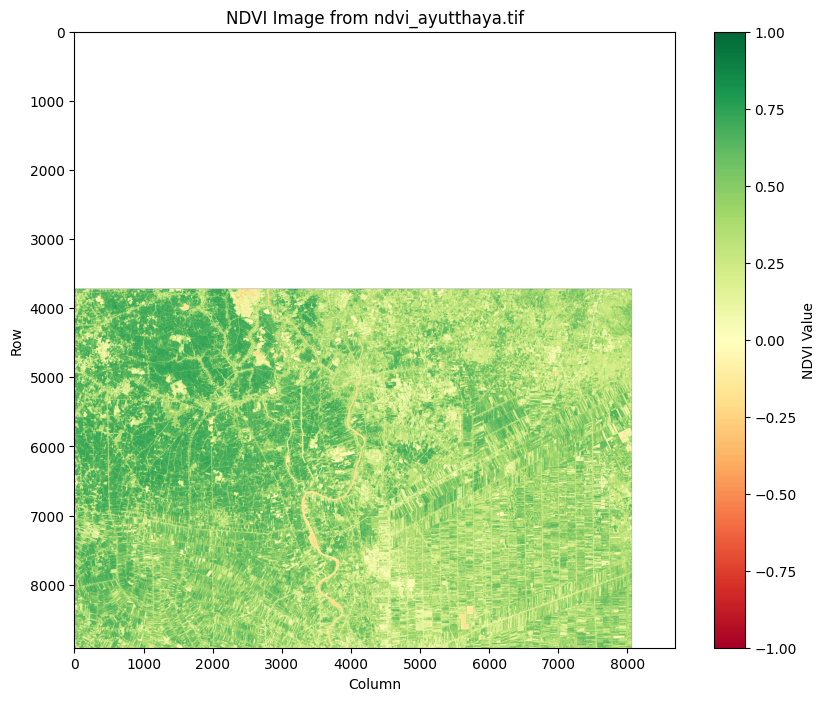

In [63]:
# แสดงภาพ Raster
plt.figure(figsize=(10, 8))
plt.imshow(raster_data, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='NDVI Value')
plt.title('NDVI Image from ' + raster_path.split('/')[-1])
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

เท่านี้คุณก็ได้แสดงผลภาพ Raster ด้วย Rasterio และ Matplotlib ในแบบฝึกหัดที่ 1 เรียบร้อยแล้วครับ! หากมีคำถามเพิ่มเติมสามารถสอบถามได้เลยครับ

### แบบฝึกหัด 2: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้

#### **ขั้นตอนที่ 1: เปิดไฟล์ Raster และดึงข้อมูลเมตา**

In [64]:
import rasterio

# ใช้ raster_path ที่ถูกกำหนดไว้แล้ว
with rasterio.open(raster_path) as dataset:
    metadata = dataset.meta
    print("ข้อมูลเมตาของภาพ Raster:")
    print(metadata)

ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 8690, 'height': 8912, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 47N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",99],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32647"]]'), 'transform': Affine(10.0, 0.0, 629130.0,
       0.0, -10.0, 1637170.0)}


#### **ขั้นตอนที่ 2: อธิบายข้อมูลเมตาที่ได้**

จากผลลัพธ์ข้างต้น เราจะเห็นข้อมูลเมตาในรูปแบบ Dictionary ซึ่งแต่ละคีย์มีความหมายดังนี้ครับ:

*   `driver`: **'GTiff'** — ระบุฟอร์แมตของไฟล์ Raster ซึ่งในที่นี้คือ GeoTIFF เป็นฟอร์แมตมาตรฐานสำหรับข้อมูลภาพภูมิสารสนเทศ
*   `dtype`: **'float32'** — ชนิดข้อมูลของแต่ละพิกเซลในภาพ หมายความว่าค่า NDVI ถูกเก็บในรูปแบบทศนิยม 32 บิต ซึ่งเหมาะสมกับการแสดงค่าดัชนีที่มีความละเอียด
*   `nodata`: **None** — ค่าพิกเซลที่ไม่มีข้อมูล (NoData Value) ถ้ามีค่านี้ จะช่วยให้เราสามารถแยกแยะพิกเซลที่มีข้อมูลจริงกับพื้นที่ว่างเปล่าได้ หากเป็น `None` หมายความว่าอาจจะไม่มีค่า NoData ถูกกำหนดไว้อย่างชัดเจน หรือไม่มีพื้นที่ NoData ในภาพนี้
*   `width`: **8690** — จำนวนคอลัมน์ของพิกเซลในภาพ (ความกว้างของภาพ)
*   `height`: **8912** — จำนวนแถวของพิกเซลในภาพ (ความสูงของภาพ)
*   `count`: **1** — จำนวนแบนด์ (Band) หรือช่องสัญญาณในภาพ ภาพ NDVI มักจะมีเพียง 1 แบนด์ที่แสดงค่าดัชนี
*   `crs`: **CRS.from_wkt('PROJCS["WGS 84 / UTM zone 47N",...]')** — ระบบพิกัดอ้างอิง (Coordinate Reference System) ของภาพ ซึ่งระบุว่าภาพนี้ถูกวางอยู่บนโลกอย่างไร ในที่นี้คือ 'WGS 84 / UTM zone 47N' ซึ่งเป็นระบบพิกัดที่ใช้กันอย่างแพร่หลายในประเทศไทย
*   `transform`: **Affine(10.0, 0.0, 629130.0, 0.0, -10.0, 1637170.0)** — อาร์เรย์ Affine Transform เป็นเมทริกซ์ที่ใช้อธิบายความสัมพันธ์ระหว่างพิกเซล (row, column) กับพิกัดทางภูมิศาสตร์ (x, y) โดยค่าต่างๆ หมายถึง:
    *   `10.0`: ขนาดของพิกเซลในแนวแกน X (Resolution X) คือ 10 เมตร
    *   `0.0`: การหมุนภาพในแนวแกน X (Rotation X)
    *   `629130.0`: พิกัด X ของมุมซ้ายบนของพิกเซลซ้ายบนสุด (Origin X)
    *   `0.0`: การหมุนภาพในแนวแกน Y (Rotation Y)
    *   `-10.0`: ขนาดของพิกเซลในแนวแกน Y (Resolution Y) คือ -10 เมตร (ค่าลบแสดงว่าพิกัด Y ลดลงเมื่อแถวเพิ่มขึ้น ซึ่งเป็นมาตรฐานของภาพ Raster)
    *   `1637170.0`: พิกัด Y ของมุมซ้ายบนของพิกเซลซ้ายบนสุด (Origin Y)

การเข้าใจข้อมูลเมตาเหล่านี้เป็นสิ่งสำคัญมากในการทำงานกับข้อมูล Raster เพราะช่วยให้เราสามารถวิเคราะห์และประมวลผลข้อมูลได้อย่างถูกต้องครับ

### แบบฝึกหัด 3: ใช้ NumPy และ Rasterio แสดงผลแผนที่ NDVI

อย่างที่ได้กล่าวไปแล้ว ไฟล์ `ndvi_ayutthaya.tif` เป็นไฟล์ NDVI ที่คำนวณมาให้แล้ว โดยมีเพียง 1 Band ดังนั้นในแบบฝึกหัดนี้ เราจะเน้นไปที่การแสดงผลแผนที่ NDVI ที่มีอยู่แล้วโดยใช้ `matplotlib` ครับ

เราจะใช้ตัวแปร `raster_data` ที่เราได้อ่านจาก Band 1 ของไฟล์ `ndvi_ayutthaya.tif` มาแล้วในแบบฝึกหัดที่ 1 มาแสดงผลได้เลยครับ

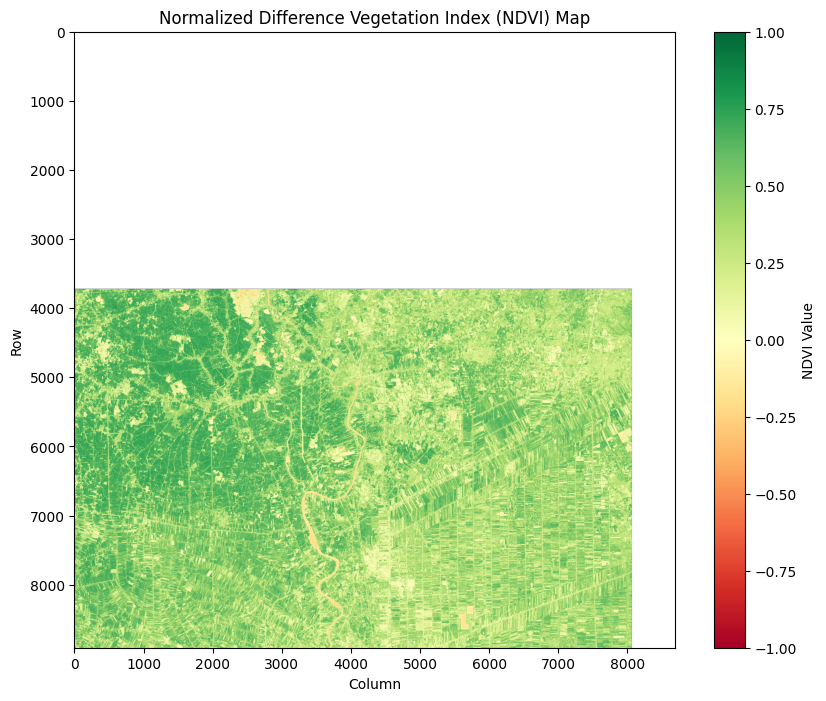

In [65]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# ตรวจสอบว่า raster_data มีอยู่ใน kernel แล้ว
# ถ้ายังไม่มี ให้รันเซลล์ d1ce27ba เพื่อโหลดข้อมูล Band 1 เข้ามา
if 'raster_data' not in locals():
    with rasterio.open(raster_path) as dataset:
        raster_data = dataset.read(1)

# แสดงผล NDVI
plt.figure(figsize=(10, 8))
plt.imshow(raster_data, cmap='RdYlGn', vmin=-1, vmax=1) # ใช้ RdYlGn colormap ที่เหมาะสำหรับ NDVI
plt.colorbar(label='NDVI Value')
plt.title('Normalized Difference Vegetation Index (NDVI) Map')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

เท่านี้คุณก็ได้แสดงผลแผนที่ NDVI โดยใช้ข้อมูลจากไฟล์ Raster ที่มีอยู่แล้วในแบบฝึกหัดที่ 3 เรียบร้อยแล้วครับ! หากคุณมีไฟล์ภาพดาวเทียมที่มี Band NIR และ Red แยกกันและต้องการลองคำนวณ NDVI จากไฟล์เหล่านั้น ก็สามารถแจ้งให้ผมทราบได้เลยครับ

### แบบฝึกที่ 4

#### **แสดงผลภาพ Raster ที่ถูกตัด (Clipped Raster)**

หลังจากที่เราได้ตัดข้อมูล Raster ไปแล้ว ตอนนี้เรามาลองแสดงผลภาพที่ถูกตัดกันดูครับ เพื่อให้เห็นว่าขอบเขตที่เรากำหนดได้ถูกนำมาใช้ตัดภาพแล้ว

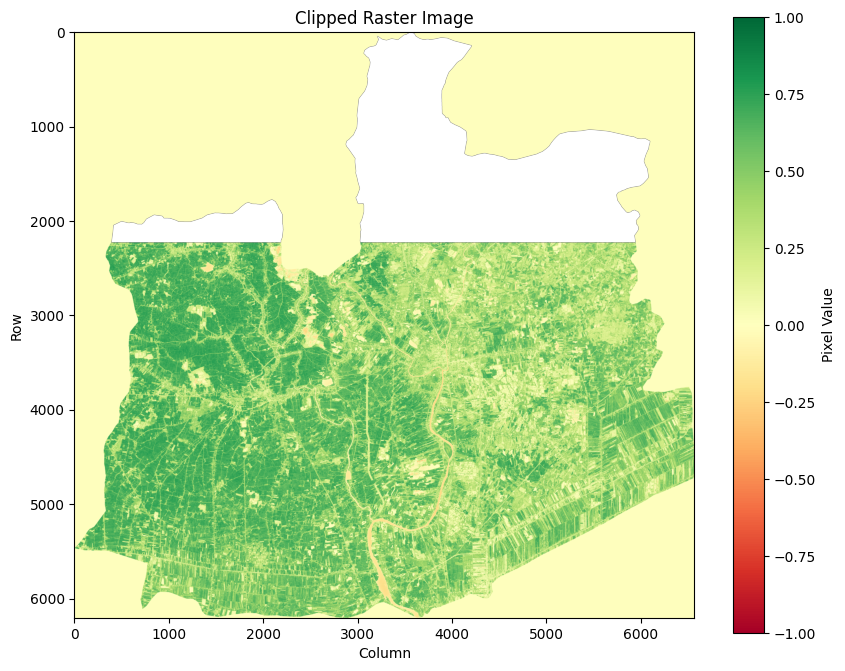

In [66]:
import matplotlib.pyplot as plt
import rasterio

# เปิดไฟล์ Raster ที่ถูกตัด (clipped_output.tif)
clipped_raster_path = "clipped_output.tif"
with rasterio.open(clipped_raster_path) as src:
    clipped_data = src.read(1) # อ่าน Band แรกของภาพที่ถูกตัด

# แสดงผลภาพ Raster ที่ถูกตัด
plt.figure(figsize=(10, 8))
plt.imshow(clipped_data, cmap='RdYlGn', vmin=-1, vmax=1) # ใช้ colormap และช่วงค่าเดียวกับ NDVI
plt.colorbar(label='Pixel Value')
plt.title('Clipped Raster Image')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()
#NDVI ไม่ครอบคลุมพื้นที่ทั้งหมดของจ.อยุธยา